<a href="https://colab.research.google.com/github/2BerbyMarty2/search-algorithms-2026/blob/main/BestFirstSearch_Maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.artist import get

In [85]:
def get_coords(node_id):
    # If it's a list, convert every ID in that list to a coordinate tuple
    if isinstance(node_id, list):
        return [(n // 6, n % 6) for n in node_id]

    # Otherwise, treat it as a single integer ID
    return (node_id // 6, node_id % 6)

def get_node(coords):
    if isinstance(coords, (int, float)):
        return int(coords)
    return coords[0] * 6 + coords[1]

In [86]:
def setup_maze():
  start_id = random.randint(0, 11)
  goal_id = random.randint(24, 35)

  all_nodes = list(range(36))
  valid_barriers = [n for n in all_nodes if n!= start_id and n!= goal_id]
  barriers = random.sample(valid_barriers, 4)

  return {
      'start': start_id,
      'goal': goal_id,
      'barriers': barriers
  }

In [87]:
def draw_maze(maze_nodes, path=None):
    fig, ax = plt.subplots(figsize=(5, 5))

    # Grid Setup
    labels = range(6)
    centers = np.arange(0.5, 6.0)
    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xticks(range(7), minor=True)
    ax.set_yticks(range(7), minor=True)
    ax.grid(True, which='minor', color='black', linestyle='-')
    ax.tick_params(which='major', length=0)
    ax.xaxis.tick_top()
    ax.invert_yaxis()
    ax.set_xlim(0, 6)
    ax.set_ylim(6, 0)

    # 1. Draw Start, Goal, and Barriers
    start_node = maze_nodes['start']
    goal_node = maze_nodes['goal']
    barriers = maze_nodes['barriers']

    ax.add_patch(patches.Rectangle(get_coords(start_node), 1, 1, color='green', alpha=0.8, label='Start'))
    ax.add_patch(patches.Rectangle(get_coords(goal_node), 1, 1, color='red', alpha=0.8, label='Goal'))

    for barrier_id in barriers:
        ax.add_patch(patches.Rectangle(get_coords(barrier_id), 1, 1, color='black', alpha=0.9))

    # 2. Draw Background Numbers
    for i in range(36):
        x, y = get_coords(i)

        # If box is colored, use white text; otherwise, faint black
        if i == start_node or i == goal_node or i in barriers:
            t_color, t_alpha = 'white', 0.9
        else:
            t_color, t_alpha = 'black', 0.2

        ax.text(x + 0.5, y + 0.5, str(i),
                va='center', ha='center',
                fontsize=10, color=t_color, weight='bold', alpha=t_alpha)

    # 3. Draw Path and Circulated Numbers
    if path:
        path_coords = [get_coords(node_id) for node_id in path]
        path_x = [c[0] + 0.5 for c in path_coords]
        path_y = [c[1] + 0.5 for c in path_coords]

        # Draw the blue line first (zorder 4)
        ax.plot(path_x, path_y, color='blue', linewidth=3, alpha=0.6, zorder=4, label='Path')

        # Circulate each number on the path
        for node_id in path:
            cx, cy = get_coords(node_id)
            center_x, center_y = cx + 0.5, cy + 0.5

            # Draw a white circle with a blue outline (zorder 5)
            circle = patches.Circle((center_x, center_y), 0.35,
                                    facecolor='white', edgecolor='blue',
                                    linewidth=2, zorder=5)
            ax.add_patch(circle)

            # Draw the number inside the circle (zorder 6)
            ax.text(center_x, center_y, str(node_id),
                    va='center', ha='center',
                    fontsize=11, color='black', weight='bold', zorder=6)

        # Directional arrows (zorder 3 so they sit behind circles)
        if len(path_x) > 1:
            ax.quiver(path_x[:-1], path_y[:-1],
                      np.diff(path_x), np.diff(path_y),
                      scale_units='xy', angles='xy', scale=1, color='blue', alpha=0.3, zorder=3)

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

In [88]:
sample_maze = setup_maze()
print(sample_maze)

{'start': 0, 'goal': 28, 'barriers': [7, 18, 22, 16]}


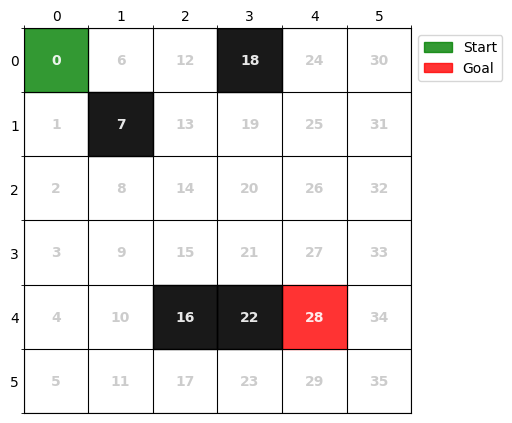

In [89]:
draw_maze(sample_maze)

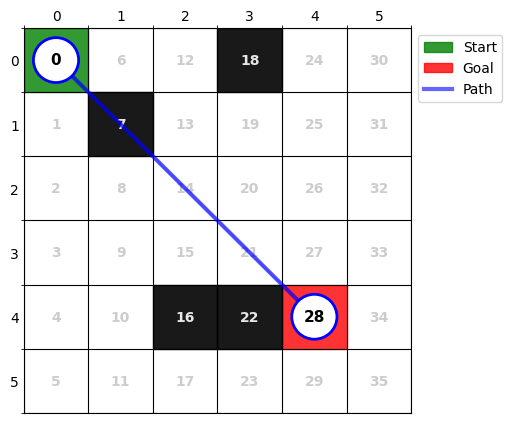

In [90]:
draw_maze(sample_maze, [sample_maze['start'],sample_maze['goal']])

In [91]:
def get_neighbors(node_id, barriers):
    # Rule (b): Convert current ID to coordinates to find neighbors
    x, y = get_coords(node_id)
    neighbors = []

    # Check all 8 directions (Horizontal, Vertical, Diagonal)
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue

            nx, ny = x + dx, y + dy

            # Rule (c): Stay within 6x6 grid and avoid barriers
            if 0 <= nx < 6 and 0 <= ny < 6:
                # Convert back to ID: ID = x*6 + y (based on your //6 and %6 logic)
                neighbor_id = nx * 6 + ny
                if neighbor_id not in barriers:
                    neighbors.append(neighbor_id)

    # Rule (a): Process neighbors in increasing order of ID
    neighbors.sort()
    return neighbors

In [92]:
def chebyshev_distance(node_id, goal_id):
    x1, y1 = get_coords(node_id)
    x2, y2 = get_coords(goal_id)

    return max(abs(x1 - x2), abs(y1 - y2))

In [93]:
import heapq

def best_first_search(maze_data):
    # Extract maze components
    start_node = maze_data['start']
    goal_node = maze_data['goal']
    barriers = maze_data['barriers']

    # Priority queue: (heuristic_cost, node)
    open_list = []
    heapq.heappush(open_list, (chebyshev_distance(start_node, goal_node), start_node))

    # Tracking structures
    visited_nodes = []      # Order of exploration (IMPORTANT)
    closed_set = set()      # Visited nodes
    parent = {}             # For path reconstruction

    result_found = False
    final_path = None

    # Main loop
    while open_list:
        heuristic_cost, current_node = heapq.heappop(open_list)

        # Skip if already processed
        if current_node in closed_set:
            continue

        # Mark visited
        closed_set.add(current_node)
        visited_nodes.append(current_node)

        # Goal check
        if current_node == goal_node:
            result_found = True

            # Reconstruct path
            path = []
            node = current_node
            while node in parent:
                path.append(node)
                node = parent[node]
            path.append(start_node)

            final_path = path[::-1]
            break

        # Explore neighbors (in increasing order)
        for neighbor in sorted(get_neighbors(current_node, barriers)):
            if neighbor in closed_set:
                continue

            # Assign parent if not already assigned
            if neighbor not in parent:
                parent[neighbor] = current_node

            # Compute heuristic (NO accumulation)
            h_value = chebyshev_distance(neighbor, goal_node)

            heapq.heappush(open_list, (h_value, neighbor))

    # Time calculation
    time_taken = len(visited_nodes)

    return {
        "result_found": result_found,
        "final_path": final_path,
        "visited_nodes": visited_nodes,
        "time_taken": time_taken
    }

In [94]:
a = setup_maze()

In [95]:
a

{'start': 7, 'goal': 31, 'barriers': [4, 12, 24, 19]}

In [96]:
b = best_first_search(a)

In [97]:
b

{'result_found': True,
 'final_path': [7, 13, 18, 25, 31],
 'visited_nodes': [7, 13, 18, 25, 31],
 'time_taken': 5}

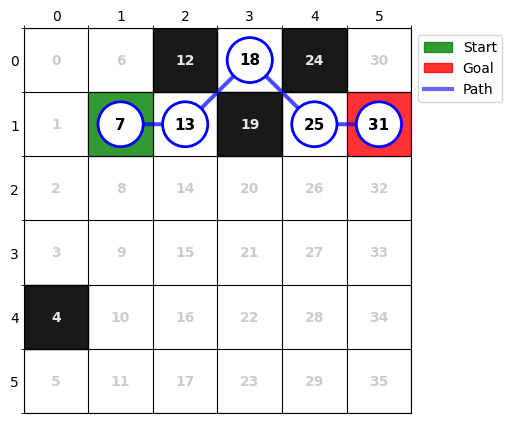

In [98]:
draw_maze(a, b['final_path'])